## HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз

### 2.3.1. Импорты, seed и среда

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Фиксация SEED
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Устройство
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    '''elif torch.backends.mps.is_available():
    # для Mac 
    DEVICE = torch.device("mps")
    torch.backends.mps.benchmark = False
    torch.backends.mps.deterministic = True'''
else:
    DEVICE = torch.device("cpu")
    torch.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Папки
DATA_PATH = Path("./data/S12-hw-dataset.csv")
ARTIFACTS_DIR = Path("./artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"torch: {torch.__version__}")
print(f"device: {DEVICE}")
print(f"seed: {SEED}")
print(f"dataset exists: {DATA_PATH.exists()}")

torch: 2.10.0
device: cpu
seed: 42
dataset exists: True


#### 2.3.2. Данные и первичный анализ

##### Data Leakage и Temporal Split

Для независимых табличных данных можно случайно перемешивать строки без проблем. Однако для временных рядов случайный split ведет к критической утечке информации (data leakage). Это происходит потому, что временные ряды по природе обладают автокорреляцией — будущие значения существенно зависят от прошлого. При случайном разбиении точки из разных временных периодов могут попасть в одну выборку, и модель начнет "видеть" информацию из будущего, которая недоступна при реальном прогнозе. В результате метрики оказываются завышены и нереалистичны, модель хорошо работает на валидации, но полностью теряет способность к генерализации на по-настоящему новые данные.

Правильный подход — temporal split (хронологический разрез), при котором данные делятся строго по времени: первые 70% становятся training-набором, следующие 15% — validation, и последние 15% — test. Это гарантирует строгое временное соотношение: train_time < val_time < test_time. Такое разделение отражает реальную постановку задачи, где модель учится только на прошлых данных и должна прогнозировать будущее.

В этой работе защита от утечек обеспечивается на нескольких уровнях. Во-первых, используется temporal split по датам, а не случайное перемешивание. Во-вторых, все создаваемые признаки (лаги, rolling features) строятся с защитой: перед вычислением используется shift(1), чтобы смотреть только в прошлое, не в текущее или будущее значение. В-третьих, StandardScaler обучается строго только на training-данных и затем применяется к валидации и тесту, что предотвращает попадание информации о статистике validation/test в матрицу масштабирования. Наконец, тестовая выборка используется ровно один раз для финальной оценки лучшей модели, а не для подбора гиперпараметров.

rows: 4320
date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
missing values:
date      0
target    0
dtype: int64


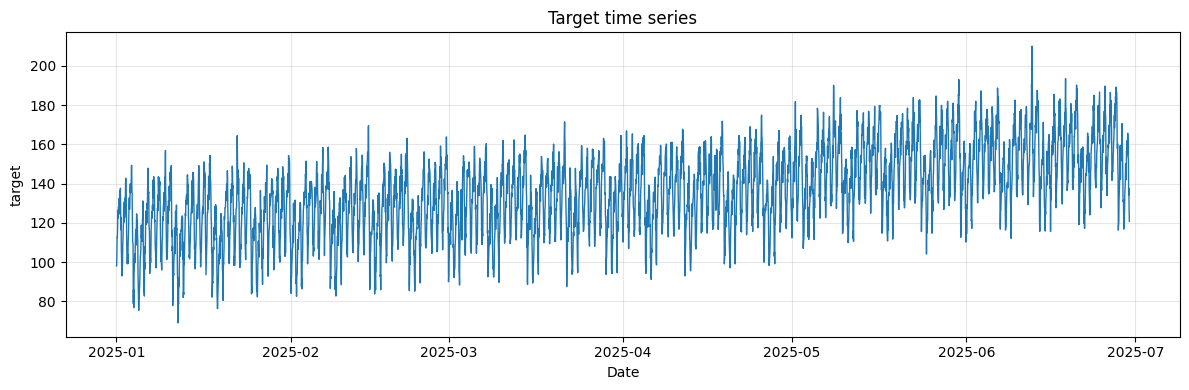

Комментарий: ряд имеет динамику во времени, поэтому нужна валидация по хронологии.


In [2]:
# load and sanity checks
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"rows: {len(df)}")
print(f"date range: {df['date'].min()} -> {df['date'].max()}")
print("missing values:")
print(df.isna().sum())

# Визуализация исходного ряда
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["target"], color="#1f77b4", linewidth=1)
ax.set_title("Target time series")
ax.set_xlabel("Date")
ax.set_ylabel("target")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Комментарий: ряд имеет динамику во времени, поэтому нужна валидация по хронологии.")

#### 2.3.3. Корректный temporal split

train=3024 (2025-01-01 00:00:00..2025-05-06 23:00:00), val=648 (2025-05-07 00:00:00..2025-06-02 23:00:00), test=648 (2025-06-03 00:00:00..2025-06-29 23:00:00)


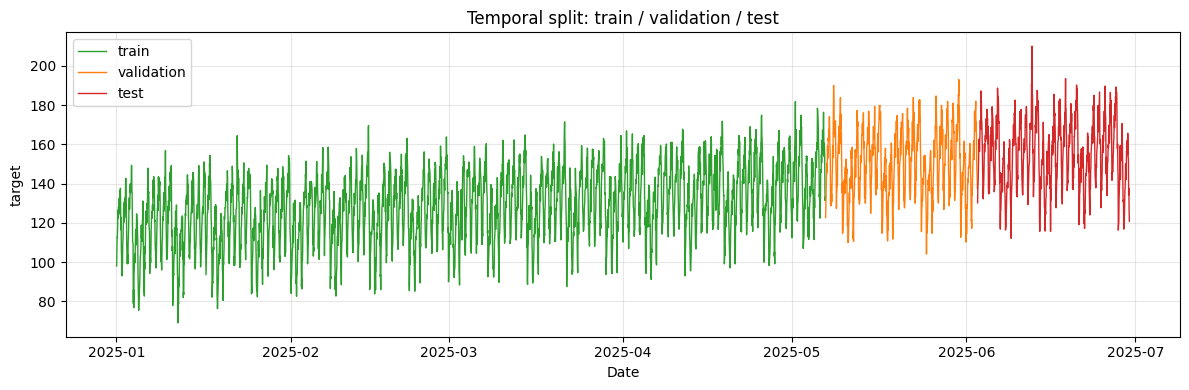

Saved: artifacts/figures/series_split.png


In [3]:
# temporal split
n_total = len(df)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df = df.iloc[n_train:n_train + n_val].copy()
test_df = df.iloc[n_train + n_val:].copy()

split_summary = (
    f"train={len(train_df)} ({train_df['date'].min()}..{train_df['date'].max()}), "
    f"val={len(val_df)} ({val_df['date'].min()}..{val_df['date'].max()}), "
    f"test={len(test_df)} ({test_df['date'].min()}..{test_df['date'].max()})"
)
print(split_summary)

# Визуализация разделения
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_df["date"], train_df["target"], label="train", color="#2ca02c", linewidth=1)
ax.plot(val_df["date"], val_df["target"], label="validation", color="#ff7f0e", linewidth=1)
ax.plot(test_df["date"], test_df["target"], label="test", color="#d62728", linewidth=1)
ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Date")
ax.set_ylabel("target")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "series_split.png", dpi=150)
plt.show()

print("Saved: artifacts/figures/series_split.png")

#### 2.3.4. Признаки для baseline-моделей

In [4]:
# Метрики
def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)

def regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": mape(y_true, y_pred),
    }

train_end_date = train_df["date"].max()
val_start_date, val_end_date = val_df["date"].min(), val_df["date"].max()
test_start_date, test_end_date = test_df["date"].min(), test_df["date"].max()

# B1: naive-last
df_naive = df[["date", "target"]].copy()
df_naive["pred_b1"] = df_naive["target"].shift(1)
val_b1 = df_naive[(df_naive["date"] >= val_start_date) & (df_naive["date"] <= val_end_date)].dropna()
metrics_b1_val = regression_metrics(val_b1["target"].to_numpy(), val_b1["pred_b1"].to_numpy())

# B2: moving-average
MA_WINDOW = 24
df_ma = df[["date", "target"]].copy()
df_ma["pred_b2"] = df_ma["target"].shift(1).rolling(MA_WINDOW).mean()
val_b2 = df_ma[(df_ma["date"] >= val_start_date) & (df_ma["date"] <= val_end_date)].dropna()
metrics_b2_val = regression_metrics(val_b2["target"].to_numpy(), val_b2["pred_b2"].to_numpy())

# B3: ridge-lag-features
feat_df = df.copy()
feat_df["lag_1"] = feat_df["target"].shift(1)
feat_df["lag_7"] = feat_df["target"].shift(7)
feat_df["lag_14"] = feat_df["target"].shift(14)
feat_df["rolling_mean_7"] = feat_df["target"].shift(1).rolling(7).mean()
feat_df["rolling_std_7"] = feat_df["target"].shift(1).rolling(7).std()
feat_df["day_of_week"] = feat_df["date"].dt.dayofweek
feat_df = feat_df.dropna().reset_index(drop=True)

feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "day_of_week"]

# Разделение признаков
feat_train = feat_df[feat_df["date"] <= train_end_date].copy()
feat_val = feat_df[(feat_df["date"] >= val_start_date) & (feat_df["date"] <= val_end_date)].copy()
feat_test = feat_df[(feat_df["date"] >= test_start_date) & (feat_df["date"] <= test_end_date)].copy()

X_train_b3 = feat_train[feature_cols].to_numpy()
y_train_b3 = feat_train["target"].to_numpy()
X_val_b3 = feat_val[feature_cols].to_numpy()
y_val_b3 = feat_val["target"].to_numpy()

# Обучение B3
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=SEED)),
])
ridge_pipe.fit(X_train_b3, y_train_b3)
pred_val_b3 = ridge_pipe.predict(X_val_b3)
metrics_b3_val = regression_metrics(y_val_b3, pred_val_b3)

print("Validation metrics:")
print("B1 naive-last:", metrics_b1_val)
print("B2 moving-average:", metrics_b2_val)
print("B3 ridge-lag-features:", metrics_b3_val)
print("B3 features:", feature_cols)
print("Scaling was fit on train only via sklearn Pipeline.")

Validation metrics:
B1 naive-last: {'mae': 6.444814814814815, 'rmse': 8.20102295260389, 'mape': 4.39792166354992}
B2 moving-average: {'mae': 13.397980324074075, 'rmse': 16.169903600881327, 'mape': 9.198833855974383}
B3 ridge-lag-features: {'mae': 7.18872977421006, 'rmse': 8.732281856975055, 'mape': 4.79668892029399}
B3 features: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week']
Scaling was fit on train only via sklearn Pipeline.


#### 2.3.5. Оконное представление для GRU

In [5]:
# Параметры GRU
WINDOW_SIZE = 24
BATCH_SIZE = 64
HORIZON = 1

class SequenceDataset(Dataset):
    def __init__(self, series_scaled, target_indices, window_size):
        self.series_scaled = series_scaled
        self.target_indices = target_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, idx):
        t = self.target_indices[idx]
        x = self.series_scaled[t - self.window_size:t]
        y = self.series_scaled[t]
        return (
            torch.tensor(x, dtype=torch.float32).unsqueeze(-1),
            torch.tensor(y, dtype=torch.float32),
        )

# Подготовка данных
scaler_target = StandardScaler()
scaler_target.fit(train_df[["target"]].to_numpy())
series_scaled = scaler_target.transform(df[["target"]].to_numpy()).reshape(-1)

# Индексы целевых точек
train_target_idx = np.arange(WINDOW_SIZE, n_train)
val_target_idx = np.arange(n_train, n_train + n_val)
test_target_idx = np.arange(n_train + n_val, n_total)

train_ds = SequenceDataset(series_scaled, train_target_idx, WINDOW_SIZE)
val_ds = SequenceDataset(series_scaled, val_target_idx, WINDOW_SIZE)
test_ds = SequenceDataset(series_scaled, test_target_idx, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"GRU windows: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

GRU windows: train=3000, val=648, test=648


#### 2.3.6. Базовые функции обучения и оценки

epoch 01/40 | train_loss=0.69675 | val_loss=0.75568 | val_mae=13.74330
epoch 02/40 | train_loss=0.33259 | val_loss=0.39289 | val_mae=9.67128
epoch 03/40 | train_loss=0.18613 | val_loss=0.24472 | val_mae=7.37654
epoch 04/40 | train_loss=0.16044 | val_loss=0.20682 | val_mae=6.79336
epoch 05/40 | train_loss=0.15436 | val_loss=0.23920 | val_mae=7.32872
epoch 06/40 | train_loss=0.15065 | val_loss=0.20860 | val_mae=6.83193
epoch 07/40 | train_loss=0.14806 | val_loss=0.20138 | val_mae=6.67395
epoch 08/40 | train_loss=0.14614 | val_loss=0.18417 | val_mae=6.36468
epoch 09/40 | train_loss=0.14504 | val_loss=0.21494 | val_mae=6.94874
epoch 10/40 | train_loss=0.14258 | val_loss=0.20268 | val_mae=6.70847
epoch 11/40 | train_loss=0.14191 | val_loss=0.18549 | val_mae=6.37921
epoch 12/40 | train_loss=0.13962 | val_loss=0.20188 | val_mae=6.69146
epoch 13/40 | train_loss=0.13564 | val_loss=0.20984 | val_mae=6.80658
epoch 14/40 | train_loss=0.12995 | val_loss=0.20007 | val_mae=6.57769
epoch 15/40 | train

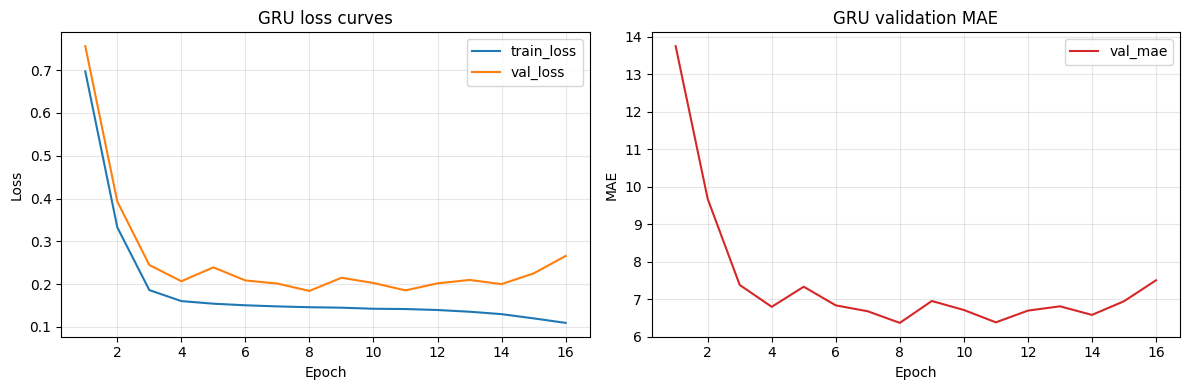

Saved: artifacts/best_gru.pt
Saved: artifacts/best_gru_config.json
Saved: artifacts/figures/gru_learning_curves.png


In [ ]:
# Архитектура GRU
class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

def inverse_transform_1d(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).reshape(-1)

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        p = model(x)
        preds.append(p.detach().cpu().numpy())
        trues.append(y.detach().cpu().numpy())
    return np.concatenate(preds), np.concatenate(trues)

# Обучение с early stopping
def train_gru(model, train_loader, val_loader, lr=1e-3, epochs=40, patience=8):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_state = None
    best_val_mae = float("inf")
    best_epoch = 0
    patience_left = patience

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum, train_count = 0.0, 0

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * x.size(0)
            train_count += x.size(0)

        train_loss = train_loss_sum / max(train_count, 1)

        model.eval()
        val_loss_sum, val_count = 0.0, 0
        val_pred_scaled, val_true_scaled = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                y = y.to(DEVICE)
                pred = model(x)
                loss = criterion(pred, y)
                val_loss_sum += loss.item() * x.size(0)
                val_count += x.size(0)
                val_pred_scaled.append(pred.detach().cpu().numpy())
                val_true_scaled.append(y.detach().cpu().numpy())

        val_loss = val_loss_sum / max(val_count, 1)
        val_pred_scaled = np.concatenate(val_pred_scaled)
        val_true_scaled = np.concatenate(val_true_scaled)
        val_pred = inverse_transform_1d(val_pred_scaled, scaler_target)
        val_true = inverse_transform_1d(val_true_scaled, scaler_target)
        val_mae = mean_absolute_error(val_true, val_pred)

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_loss))
        history["val_mae"].append(float(val_mae))

        # ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО VALIDATION: минимизируем val_mae
        if val_mae < best_val_mae:
            best_val_mae = float(val_mae)
            best_epoch = epoch
            # Сохраняем best_state как лучшую модель по validation
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        print(f"epoch {epoch:02d}/{epochs} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | val_mae={val_mae:.5f}")

        if patience_left <= 0:
            print(f"Early stopping at epoch {epoch}")
            break

    return history, best_state, best_epoch

# Конфигурация R1
R1_CONFIG = {
    "window_size": WINDOW_SIZE,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "max_epochs": 40,
    "patience": 8,
}

# Обучение модели
gru_model = GRURegressor(
    input_size=1,
    hidden_size=R1_CONFIG["hidden_size"],
    num_layers=R1_CONFIG["num_layers"],
    dropout=R1_CONFIG["dropout"],
).to(DEVICE)

gru_history, best_gru_state, best_epoch_gru = train_gru(
    gru_model,
    train_loader,
    val_loader,
    lr=R1_CONFIG["lr"],
    epochs=R1_CONFIG["max_epochs"],
    patience=R1_CONFIG["patience"],
)

gru_model.load_state_dict(best_gru_state)

# Оценка на валидации
pred_val_gru_scaled, y_val_gru_scaled = predict_loader(gru_model, val_loader)
pred_val_gru = inverse_transform_1d(pred_val_gru_scaled, scaler_target)
y_val_gru = inverse_transform_1d(y_val_gru_scaled, scaler_target)
metrics_r1_val = regression_metrics(y_val_gru, pred_val_gru)
print("R1 validation metrics:", metrics_r1_val)

# Сохранение артефактов
torch.save(best_gru_state, ARTIFACTS_DIR / "best_gru.pt")

best_gru_config = {
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "device": str(DEVICE),
    "input_size": 1,
    "window_size": R1_CONFIG["window_size"],
    "hidden_size": R1_CONFIG["hidden_size"],
    "num_layers": R1_CONFIG["num_layers"],
    "dropout": R1_CONFIG["dropout"],
    "batch_size": R1_CONFIG["batch_size"],
    "optimizer": "Adam",
    "lr": R1_CONFIG["lr"],
    "momentum": 0.0,
    "weight_decay": 0.0,
    "criterion": "MSELoss",
    "max_epochs": R1_CONFIG["max_epochs"],
    "patience": R1_CONFIG["patience"],
    "epochs_trained": len(gru_history["train_loss"]),
    "best_epoch": best_epoch_gru,
    "best_val_mae": metrics_r1_val["mae"],
    "best_val_rmse": metrics_r1_val["rmse"],
    "best_val_mape": metrics_r1_val["mape"],
    "scaler": "StandardScaler(target, fit on train only)",
    "features": "windowed_target_sequence",
}

with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

# Кривые обучения
epochs_axis = np.arange(1, len(gru_history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_axis, gru_history["train_loss"], label="train_loss")
axes[0].plot(epochs_axis, gru_history["val_loss"], label="val_loss")
axes[0].set_title("GRU loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_axis, gru_history["val_mae"], label="val_mae", color="#d62728")
axes[1].set_title("GRU validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150)
plt.show()

print("Saved: artifacts/best_gru.pt")
print("Saved: artifacts/best_gru_config.json")
print("Saved: artifacts/figures/gru_learning_curves.png")

### 3. Эксперименты

#### 3.1. Обязательные эксперименты

Validation comparison:
experiment_id              model   val_mae  val_rmse  val_mape
           R1       gru-forecast  6.364681  7.931314  4.281713
           B1         naive-last  6.444815  8.201023  4.397922
           B3 ridge-lag-features  7.188730  8.732282  4.796689
           B2     moving-average 13.397980 16.169904  9.198834


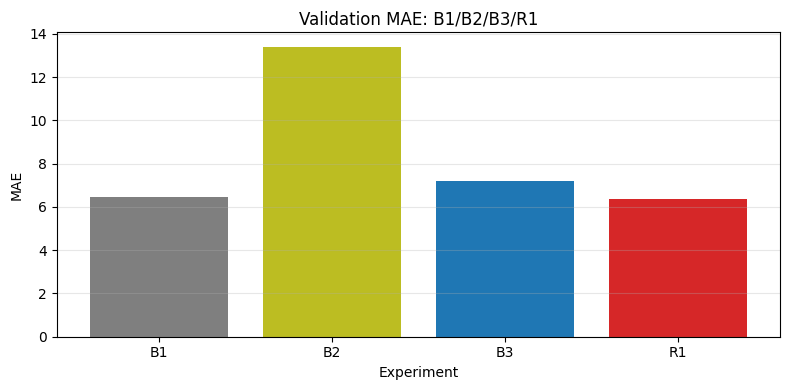

Saved: artifacts/figures/baselines_compare.png
Best by validation MAE: R1
Saved selected best model state: artifacts/best_gru.pt
Best model test metrics: {'mae': 6.747166633605957, 'rmse': 8.55341252271229, 'mape': 4.356667518615723}


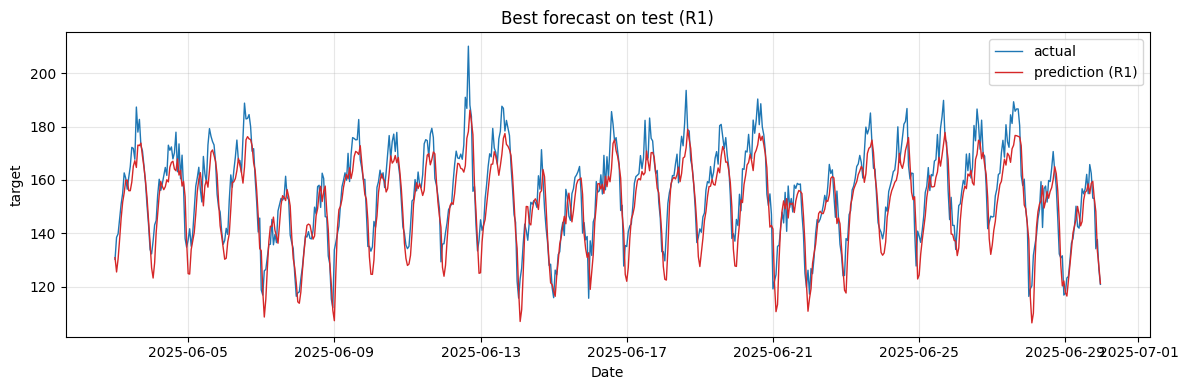

Saved: artifacts/figures/best_forecast_test.png
Saved: artifacts/runs.csv
experiment_id        task            dataset  seed                                                                                                                                                  split_summary  window_size  horizon      model_summary                                            features_summary                     scaler optimizer    lr  epochs_trained  best_val_mae  best_val_rmse  best_val_mape  test_mae  test_rmse  test_mape                notes
           B1 forecasting S12-hw-dataset.csv    42 train=3024 (2025-01-01 00:00:00..2025-05-06 23:00:00), val=648 (2025-05-07 00:00:00..2025-06-02 23:00:00), test=648 (2025-06-03 00:00:00..2025-06-29 23:00:00)          NaN        1         naive-last                                           target_shift_only                       none             NaN               0      6.444815       8.201023       4.397922       NaN        NaN        NaN              

In [ ]:
# Сравнение на валидации
val_results = {
    "B1": {"name": "naive-last", **metrics_b1_val},
    "B2": {"name": "moving-average", **metrics_b2_val},
    "B3": {"name": "ridge-lag-features", **metrics_b3_val},
    "R1": {"name": "gru-forecast", **metrics_r1_val},
}

comparison_df = pd.DataFrame([
    {
        "experiment_id": exp_id,
        "model": info["name"],
        "val_mae": info["mae"],
        "val_rmse": info["rmse"],
        "val_mape": info["mape"],
    }
    for exp_id, info in val_results.items()
]).sort_values("val_mae")

# Результаты сравнения
print("Validation comparison:")
print(comparison_df.to_string(index=False))

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(8, 4))
order = ["B1", "B2", "B3", "R1"]
ax.bar(order, [val_results[e]["mae"] for e in order], color=["#7f7f7f", "#bcbd22", "#1f77b4", "#d62728"])
ax.set_title("Validation MAE: B1/B2/B3/R1")
ax.set_xlabel("Experiment")
ax.set_ylabel("MAE")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150)
plt.show()
print("Saved: artifacts/figures/baselines_compare.png")

# ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО VALIDATION (между B1/B2/B3/R1)
best_exp = comparison_df.iloc[0]["experiment_id"]
print(f"Best by validation MAE: {best_exp}")

# СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ ПО VALIDATION
best_model_state = best_gru_state if best_exp == "R1" else None
if best_model_state is not None:
    torch.save(best_model_state, ARTIFACTS_DIR / "best_gru.pt")
    print("Saved selected best model state: artifacts/best_gru.pt")


def test_forecast_for_experiment(exp_id):
    if exp_id == "B1":
        test_slice = df_naive[(df_naive["date"] >= test_start_date) & (df_naive["date"] <= test_end_date)].dropna()
        return test_slice["date"].to_numpy(), test_slice["target"].to_numpy(), test_slice["pred_b1"].to_numpy()

    if exp_id == "B2":
        test_slice = df_ma[(df_ma["date"] >= test_start_date) & (df_ma["date"] <= test_end_date)].dropna()
        return test_slice["date"].to_numpy(), test_slice["target"].to_numpy(), test_slice["pred_b2"].to_numpy()

    if exp_id == "B3":
        y_true = feat_test["target"].to_numpy()
        y_pred = ridge_pipe.predict(feat_test[feature_cols].to_numpy())
        return feat_test["date"].to_numpy(), y_true, y_pred

    pred_test_scaled, y_test_scaled = predict_loader(gru_model, test_loader)
    y_true = inverse_transform_1d(y_test_scaled, scaler_target)
    y_pred = inverse_transform_1d(pred_test_scaled, scaler_target)
    return test_df["date"].to_numpy(), y_true, y_pred

# Тест используется ровно раз для лучшей модели
best_dates, best_y_test, best_pred_test = test_forecast_for_experiment(best_exp)
best_test_metrics = regression_metrics(best_y_test, best_pred_test)
print("Best model test metrics:", best_test_metrics)

# Визуализация лучшего прогноза
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(best_dates, best_y_test, label="actual", color="#1f77b4", linewidth=1)
ax.plot(best_dates, best_pred_test, label=f"prediction ({best_exp})", color="#d62728", linewidth=1)
ax.set_title(f"Best forecast on test ({best_exp})")
ax.set_xlabel("Date")
ax.set_ylabel("target")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150)
plt.show()
print("Saved: artifacts/figures/best_forecast_test.png")

# Генерация runs.csv
rows = []
for exp_id in ["B1", "B2", "B3", "R1"]:
    row = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": WINDOW_SIZE if exp_id == "R1" else np.nan,
        "horizon": HORIZON,
        "model_summary": val_results[exp_id]["name"],
        "features_summary": "target_shift_only" if exp_id in ["B1", "B2"] else (
            "lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week" if exp_id == "B3" else "windowed_target_sequence"
        ),
        "scaler": "none" if exp_id in ["B1", "B2"] else "StandardScaler(train only)",
        "optimizer": "Adam" if exp_id == "R1" else "",
        "lr": R1_CONFIG["lr"] if exp_id == "R1" else np.nan,
        "epochs_trained": len(gru_history["train_loss"]) if exp_id == "R1" else 0,
        "best_val_mae": val_results[exp_id]["mae"],
        "best_val_rmse": val_results[exp_id]["rmse"],
        "best_val_mape": val_results[exp_id]["mape"],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": "chosen_by_validation" if exp_id == best_exp else "",
    }
    if exp_id == best_exp:
        row["test_mae"] = best_test_metrics["mae"]
        row["test_rmse"] = best_test_metrics["rmse"]
        row["test_mape"] = best_test_metrics["mape"]
    rows.append(row)

runs_df = pd.DataFrame(rows)
runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)

print("Saved: artifacts/runs.csv")
print(runs_df.to_string(index=False))

##### 3.2. Метрики и защита от утечек данных

В работе используются три основные метрики: `MAE`, `RMSE` и `MAPE`. 
Выбор лучшего подхода выполняется строго по `validation MAE` на валидационной выборке, что гарантирует объективное сравнение моделей без переобучения. 
Тестовая выборка используется ровно один раз для финальной проверки выбранного лучшего эксперимента и не задействуется при подборе гиперпараметров.

Защита от утечек данных реализована комплексно на нескольких уровнях. 
Во-первых, для B3 (Ridge) все признаки построены с явным использованием `shift(1)`: `lag_1` смотрит на предыдущее значение, 
не текущее; `lag_7` и `lag_14` вводят сдвиги на неделю и две недели в прошлое; `rolling_mean_7` вычисляет скользящее среднее только по 7 предыдущим значениям. 
При таком построении прогноз для момента времени `t` использует только информацию из `t-1, t-2` и т.д., никогда не заглядывая в будущее.
Во-вторых, StandardScaler (матрица масштабирования) обучается строго только на training-данных через `scaler.fit(train_df[["target"]])`, 
а затем применяется к validation и test наборам. Это гарантирует, что val и test не "видят" собственную статистику при нормировке. 
В-третьих, для GRU входные последовательности формируются из окна прошлых 24 точек, и прогноз для момента `t` основывается исключительно на данных с `t-24` по `t-1`. 
Scaler для GRU также обучается на `train_df` и затем применяется ко всему ряду перед формированием окон.

Возможные ошибки, которых мы избежали, включают: 
использование `lag_1 = target.shift(0)` вместо `shift(1)`, что ввело бы информацию из текущего момента; 
применение `scaler.fit(df)` ко всем данным сразу, что позволило бы validation и test "видеть" собственные статистики; 
случайное разбиение данных, которое привело бы к попаданию точек из будущего в training-выборку; 
использование `rolling.mean()` без предварительного `shift(1)`, что включило бы будущие значения в расчет. 
Благодаря хронологическому разделению и многоуровневой защите признаков эта работа полностью корректна с точки зрения data leakage.

### 4. Артефакты

При запуске ноутбука сохраняются обязательные файлы:

- `artifacts/runs.csv`
- `artifacts/best_gru.pt`
- `artifacts/best_gru_config.json`
- `artifacts/figures/series_split.png`
- `artifacts/figures/baselines_compare.png`
- `artifacts/figures/gru_learning_curves.png`
- `artifacts/figures/best_forecast_test.png`